# Aula 22

# Redes Complexas

### Eduardo Lobo Lustosa Cabral


## 1. Objetivo

Aprsentar a classe Funcional do Keras.

Apresentar como criar algumas redes complexas no Keras.

### Carregar bibliotecas principais

Em primeiro lugar é necessário importar alguns pacotes do Python que serão usados:
    
- Numpy pacote de cálculo científico com Python
- Matplotlib biblioteca para gerar gráficos em Python
- TensorFlow

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

## 2. Classe Funcional do Keras

Modelo sequencial do Keras não serve para RNAs que possuem mais do que uma entrada ou uma saída e também para RNAs mais complexas que possuem laços ou estruturas em paralelo.

Para configurar uma RNA com fluxo de informação não sequencial tem que usar a Classe Funcional do Keras (“Functional API”).

A classe Funcional do Keras permite construir RNAs com vários ramos, várias entradas, várias saídas etc.

A classe Funcional do Keras é muito flexível e permite construir praticamente qualquer tipo de RNA.

#### Exemplo de uma RNA configurada com a classe de modelo funcional do Keras

In [ ]:
# Importa classe funcional
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense

# Configuração da RNA
X = Input(shape=(32,))
A = Dense(64, activation='relu')(X)
Y = Dense(16, activation='softmax')(A)

# Criação da RNA
rna = Model(inputs=X, outputs=Y)

rna.summary()

- Essa RNA inclui todas as camadas necessárias para o cálculo de Y dado X.

#### Comparação entre uma RNA criada com a classe sequencial e a mesma RNA cria com a classe funcional

In [ ]:
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras import layers

# RNA criada com classe sequencial da forma que conhecemos
rna_seq = Sequential()
rna_seq.add(layers.Dense(128, activation='relu',input_shape=(64,)))
rna_seq.add(layers.Dense(32, activation='relu'))
rna_seq.add(layers.Dense(10, activation='softmax'))
rna_seq.summary()
print('\n')

# Mesma RNA criada com classe funcional
x0 = layers.Input(shape=(64,))
x = layers.Dense(128, activation='relu', name='teste')(x0)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(10, activation='softmax')(x)
rna = Model(x0, output)
rna.summary()

## 3. Redes complexas

Muitas aplicações exigem RNAs mais complexas do que as que já estudamos, como por exemplo:

- Detecção e localização de objetos em imagens $\to$ nesse caso a RNA tem que ter várias saídas de tipos diferentes;


- RNAs que processam várias entradas em paralelo com a mesma RNA (visão estéreo e one-shot learning) $\to$ nesse caso a RNA tem dois ramos iguais (RNA Siamesa);


- Transferência de estilo $\to$ nesse caso tem-se duas imagens que são processadas em paralelo por duas RNAs iguais e as saídas são comparadas para gerar o erro de treinamento.


- Segmentação de imagens, autoencoders e GANs $\to$ nesses casos a rede tem que ser capaz de gerar imagens a partir de vetores com dimensão muito menor ou criar imagens de dimensão maior do que a imagem recebida como dado de entrada.

### 3.1 RNA com várias saídas

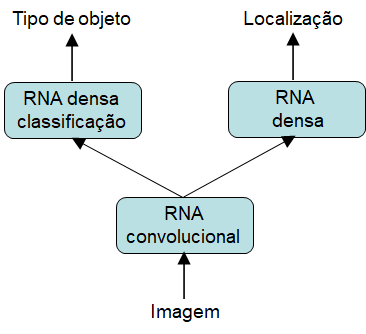

(rna_complexa_2.png)

#### Exemplo de configuração no Keras

- Parte convolucional:
    - Uma camada convolucionial com 128 filtros de dimensão 3x3 e função de ativação Relu
    - Uma camada Maxpooling
    - Uma camada convolucionial com 256 filtros de dimensão 3x3 e função de ativação Relu
    - Uma camada Maxpooling
    
    
- Parte densa para classificação:
    - Uma camada tipo densa com 64 neurônios e função de ativação Relu
    - Uma camada de saída com 10 neurônios (10 classes) e função de ativação softmax
    
    
- Parte densa para localização do objeto:
    - Uma camada tipo densa com 64 neurônios e função de ativação Relu
    - Uma camada de saída com 4 neurônios e função de ativação sigmoide

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Definição da entrada
input_shape = (64, 64, 3)
X = layers.Input(shape=input_shape)

# Configuração da parte convoluciona
X1 = layers.Conv2D(128, (3,3), activation='relu')(X)
X1 = layers.MaxPooling2D(2, 2)(X1)
X2 = layers.Conv2D(256, (3,3), activation='relu')(X1)
X3 = layers.MaxPooling2D(2, 2)(X2)

# Camada de Flatten
X4 = layers.Flatten()(X3)

# Rede de classificação para 10 classes
X5 = layers.Dense(64, activation='relu')(X4)
Y_class = layers.Dense(10, activation='softmax', name='classe')(X5)

# Rede de localização
X6 = layers.Dense(64, activation='relu')(X4)
Y_loc = layers.Dense(4, activation='sigmoid', name='localizacao')(X6)

# Criação da RNA
rna = Model(inputs=X, outputs=[Y_class, Y_loc])

# Mostra resumo da RNA
rna.summary()

In [ ]:
# Cria um gráfico da RNA no arquivo rna.png
from tensorflow.keras.utils import plot_model
plot_model(rna, to_file='rna_detect.png', show_shapes=True, show_layer_activations=True, show_layer_names=True)

#### Compilação de uma RNA com várias saídas

Para compilar um RNA com várias saídas deve-se especificar uma função de custo e uma métrica para cada saída. Além disso é necessário definir pesos para cada função de custo de forma a compor a função de custo global, que é utilizada no treinamento da rede.

A célula abaixo mostra um exemplo de como compilar a rede configurada anteriormente que possui uma saída com 10 neurônios para classificação multiclasse e outra saída com 4 neurônios para ajuste de um função. Para essas saídas são definidas:

- Saída de classificação: função de custo `categorical_crossentropy` e métrica `accuracy`

- Saída de ajuste de função: função de custo `mse` e métrica `mae`

- Pesos para as funções de custo: 2 para `localização (mse)` e 1 para `classificação (categorical_crossentropy)`

In [ ]:
# importa do keras a classe dos otimizadores
from tensorflow.keras import optimizers

# Configuração do otimizador
adam = optimizers.Adam(learning_rate=0.001)

rna.compile(optimizer=adam,
            loss={
                  'classe': 'categorical_crossentropy',
                  'localizacao': 'mse'},
            loss_weights={
                  'localizacao': 2.0,
                  'classe': 1.0},
            metrics={
                  'classe': 'accuracy',
                  'localizacao': 'mae'})

- Observa-se que os nomes `classe` e `localizacao` usados na compilação, são os nomes definidos para as duas camadas de saída dessa rede.

#### Treinamento da RNA

O treinamento de uma RNA com várias saídas usando o método `fit` é realizado da mesma forma que para qualquer outra rede. A única diferença é que deve-se passar todas as saídas ao executar o método `fit`. A célula baixo mostra como treinar essa RNA com duas saídas.

In [ ]:
history = rna.fit(x_train, [y_class_train, y_loc_train], epochs=100, verbose=2, validation_data=(x_val, [y_class_val, y_loc_val]))

### 3.2 RNA com mais de um ramo (siamesa)

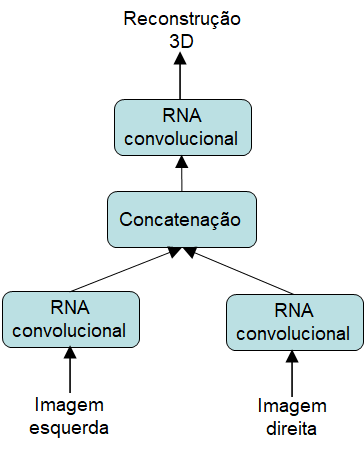

(rna_complexa_3.png)

#### Exemplo de configuração no Keras

- Rede convolucional siamesa:
    - Uma camada convolucionial com 128 filtros de dimensão 3x3 e função de ativação Relu
    - Uma camada convolucionial com 256 filtros de dimensão 3x3 e função de ativação Relu
    
    
- Parte convolucional de reconstrução 3D
    - Uma camada convolucionial com 128 filtros de dimensão 3x3, stride = (2,1) e função de ativação Relu
    - Uma camada convolucionial com 32 filtros de dimensão 3x3 e função de ativação Relu
    - Uma camada convolucionial com 1 filtro de dimensão 1x1 e função de ativação Relu

A camada de saída deve ter somente um filtro porque o que é desejado no caso são as distâncias dos objetos da cena em relação às cameras.

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model, Sequential

# Configuração da rede convolucional siamesa
img_dim = (120, 160, 3)

rna_siam = Sequential()
rna_siam.add(layers.Conv2D(128, (3,3), activation='relu', padding='same', input_shape=img_dim))
rna_siam.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))

# Mostra resumo da RNA
rna_siam.summary()

In [ ]:
# Define as entradas da rede
img_esq = layers.Input(shape=img_dim, name='img_esq')
img_dir = layers.Input(shape=img_dim, name='img_dir')

# Processa imagens para gerar imagens de características
carac_esq = rna_siam(img_esq)
carac_dir = rna_siam(img_dir)

# Une as imagens de características
X_con = layers.concatenate([carac_esq, carac_dir], axis=2)

# Processa imagens de caracteríticas para gerar imagem de 3D
X1 = layers.Conv2D(128, (3,3), strides=(1,2), activation='relu', padding='same')(X_con)
X2 = layers.Conv2D(32, (3,3), activation='relu', padding='same')(X1)
Y = layers.Conv2D(1, (1,1), activation='relu')(X2)

# cria rede siamesa
rna = Model(inputs=[img_esq, img_dir], outputs=Y)

# Mostra resumo da RNA
rna.summary()

In [ ]:
# Cria um gráfico da RNA no arquivo rna.png
plot_model(rna, to_file='rna_siam.png', show_shapes=True, show_layer_activations=True, show_layer_names=True)

### 3.3 RNA com diferentes tipos de entradas:

Uma configuração de modelo muito comum é uma rede com diferentes tipos de camadas, tal como mostrada na figura a baixo.

Esse tipo de modelo é usado em modelos generativos de imagens onde a entrada do usuário é um texto com as características da imagem desejada. Mas no treinamento o modelo tem que receber a imagem e o texto descritivo correspondenete.


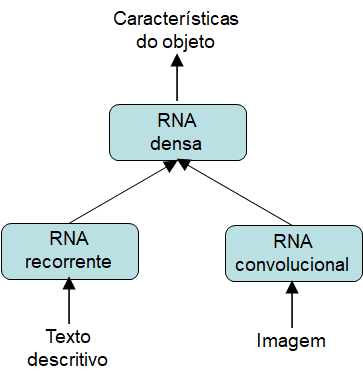

(rna_complexa_1.png)

## 4. Exemplo - rede com saídas parciais

Uma técnica utilizada para diminuir overfitting é incluir no modelo saídas no "meio" do modelo.

A ideia é que se uma parte do modelo é capaz de prever uma saída satisfatória, então, se após essa saída forem incluídas mais camadas o modelo com essas camadas adicionais vai ser capaz de melhorar as previsões. Assim, seguindo esse raciocínio colocar saídas intermediárias melhora o desempenho do modelo.

Vamos resolver um problema de classificação multiclasse para entender como funciona essa técnica.

##$ 4.1 Conjunto de dados

Vamos usa o conjunto de dados TFFlowres.

As classes de flores estão descritas por números inteiros, codificadas da seguinte forma:

- "dente de leão": 0
- "margarida": 1
- "tulipa": 2
- "girassol": 3
- "rosa": 4

Para usar as classes descritas por números inteiros, sem a necessidade de transformar em vetores "one-hot", temos que usar a função de custo `sparse_categorical_crossentropy`, que realiza essa transformação internamente de forma automática.

In [ ]:
import tensorflow_datasets as tfds

In [ ]:
train_data, test_data = tfds.load('TFFlowers', shuffle_files=True, split=['train[:80%]', 'train[-20%:]'], as_supervised=True, with_info=False)

In [ ]:
print('Número exemplos de treinamento =', len(list(train_data)))
print('Número exemplos de teste =', len(list(test_data)))

In [ ]:
# Itera no conjutno de dados pegando exemplos
for data in train_data.take(3):
    image, label = data

    print("Classe: {}".format(label))
    plt.imshow(image)
    plt.show()

In [ ]:
# Dimensão das imagens
IMAGE_SIZE = (64, 64)

# Função usada para redimensionar e normalizar as imagens
def format_image(image, label):
    image = tf.cast(image, dtype=tf.float32)
    image = tf.image.resize(image, IMAGE_SIZE)/255.
    label = tf.cast(label, tf.int32)
    return  image, {'saida1': label, 'saida2': label}

# Define tamanho do lote de dados de treinamento e validação
BATCH_SIZE = 128

# Cria lotes de dados usando o método map() para chamar a função format_image()
train_batches = train_data.map(format_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)
test_batches = test_data.map(format_image, num_parallel_calls=tf.data.AUTOTUNE).batch(BATCH_SIZE)

In [ ]:
for img, lb in train_batches.take(1):
    print('Dimensão de um lote de imagens:', img.shape)
    print('Dimensão de um lote da saídas:', lb['saida1'].shape)
    print('Dimensão de um lote da saídas:', lb['saida2'].shape)

In [ ]:
from tensorflow.keras import layers
from tensorflow.keras.models import Model

# Definição da entrada
input_shape = (64, 64, 3)

# Camada de entrada
X0 = layers.Input(shape=input_shape)

# Estica imagem
X = layers.Flatten()(X0)

# Inclui camadas densas
X = layers.Dense(256, activation='relu')(X)
X = layers.Dropout(0.2)(X)
X = layers.Dense(256, activation='relu')(X)
X = layers.Dropout(0.2)(X)

# Primeira saída - Camada densa de classificação com 5 classes
Y1 = layers.Dense(5, activation='softmax', name='saida1')(X)

# Inclui mais camadas densas
X = layers.Dense(256, activation='relu')(X)
X = layers.Dropout(0.2)(X)
X = layers.Dense(256, activation='relu')(X)
X = layers.Dropout(0.2)(X)

# Camada densa de classificação com 6 classes
Y2 = layers.Dense(5, activation='softmax', name='saida2')(X)

# Criação da RNA
rna = Model(inputs=X0, outputs=[Y1, Y2])

# Mostra resumo da RNA
rna.summary()

In [ ]:
# Cria um gráfico da RNA no arquivo rna.png
plot_model(rna, show_shapes=True, show_layer_names=True, show_layer_activations=True)

In [ ]:
# importa do keras a classe dos otimizadores
from tensorflow.keras import optimizers

# Configuração do otimizador
adam = optimizers.Adam(learning_rate=0.001)

rna.compile(optimizer=adam,
            loss={
                  'saida1': 'sparse_categorical_crossentropy',
                  'saida2': 'sparse_categorical_crossentropy'},
            loss_weights={
                  'saida1': 1.0,
                  'saida2': 1.0},
            metrics={
                  'saida1': 'accuracy',
                  'saida2': 'accuracy'})

In [ ]:
# Define número de épocas de treinamento
EPOCHS = 30

# Para permitir usar estrutura tf.data.Dataset
tf.config.run_functions_eagerly(True)

# Realiz ao treinamento usando os dados de treinamento e validação
history = rna.fit(train_batches,
                epochs=EPOCHS,
                validation_data=test_batches)

In [ ]:
# Salva treinamento na variável history para visualização
history_dict = history.history

# Salva custos, métricas e epocas em vetores
custo_total = history_dict['loss']
acc1 = history_dict['saida1_accuracy']
acc2 = history_dict['saida2_accuracy']

val_custo_total = history_dict['val_loss']
val_acc1 = history_dict['val_saida1_accuracy']
val_acc2 = history_dict['val_saida2_accuracy']

# Cria vetor de épocas
epocas = range(1, len(custo_total) + 1)

# Gráfico dos valores de custo
plt.plot(epocas, custo_total, 'b', label='Custo total - treinamento')
plt.plot(epocas, val_custo_total, 'r', label='Custo total - validação')
plt.title('Valor da função de custo total – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Custo')
plt.grid()
plt.legend()
plt.show()

plt.plot(epocas, acc1, 'b', label='Exatidão saida1 - treinamento')
plt.plot(epocas, acc2, 'r', label='Exatidão saida2 - treinamento')
plt.plot(epocas, val_acc1, 'g', label='Exatidão saida1 - validação')
plt.plot(epocas, val_acc2, 'y', label='Exatidão saida2 - validação')
plt.title('Valor das métricas – treinamento e validação')
plt.xlabel('Épocas')
plt.ylabel('Métricas')
plt.grid()
plt.legend()
plt.show()

In [ ]:
# Avalia desempenho da RNA para os dados de validação
eval_results = rna.evaluate(test_batches, verbose=0)
print('Custo:', eval_results[0])
print('Exatidão saída 1:', eval_results[1])
print('Exatidão saída 2:', eval_results[2])

In [ ]:
for data in test_data.map(format_image).take(5):
    # Extrai imagem e classe
    image, label = data
    yreal = label['saida1']

    # Adiciona eixo dos exemplos
    image = np.expand_dims(image, axis=0)

    # Calcula probabilidades previstas pela RNA
    yprev = rna.predict(image, verbose=0)
    y1 = yprev[1]

    # Determina classe prevista
    classe_prev = np.argmax(y1)

    # Apresenta resultados e mostra imagem
    print('\nProbabilidades =', y1)
    print("Classe real: {}".format(yreal))
    print("Classe prevista: {}".format(classe_prev))
    plt.imshow(image[0])
    plt.show()